# Customer-level churn modelling

This notebook establishes the first reproducible modelling baseline for the team.blue churn assignment. It uses the validated data layer and customer feature builder from `src/`; the notebook is responsible only for orchestration, hyperparameter search, evaluation, and interpretation.

The initial modelling questions are:

1. Can an interpretable logistic model beat the majority-class baseline?
2. Does a complex model such as XGBoost improve significantly the performance of a simpler and interpretable model such as logistic regression?
2. Does performance persist when every validation cohort occurs after its training data?

The supplied validation CSV has no target and remains untouched during model selection.

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from team_blue.workflow import prepare_training_data
from team_blue.tuning import tune_model

prepared = prepare_training_data()

X = prepared.X_train
y = prepared.y_train
cohorts = prepared.cohorts

print(f"Customers: {len(X):,}")
print(f"Features: {X.shape[1]:,}")
print(prepared.cleaning_report)

Customers: 22,673
Features: 68
CleaningReport(invalid_tenure_policy='drop_rows', conflicting_target_policy='drop_customers', input_rows=93589, output_rows=92112, input_customers=22674, output_customers=22673, invalid_tenure_rows=1467, invalid_tenure_customers=30, conflicting_target_customers=1)


In [2]:
# Show temporal folds
from team_blue.modeling import make_expanding_window_folds

folds = make_expanding_window_folds(cohorts)
tuning_folds = folds[:-1]
holdout_fold = folds[-1]

fold_summary = [
    {
        "validation_period": str(fold.validation_period),
        "training_customers": len(fold.train_index),
        "validation_customers": len(fold.validation_index),
        "purpose": (
            "Final holdout"
            if fold is holdout_fold
            else "Hyperparameter tuning"
        ),
    }
    for fold in folds
]

pd.DataFrame(fold_summary)

,validation_period,training_customers,validation_customers,purpose
0,2023-04,11945,3464,Hyperparameter tuning
1,2023-05,15409,3682,Hyperparameter tuning
2,2023-06,19091,3582,Final holdout


# Tuning
In this sections models will be tunned (both logistic and XGBoost). We will iterate over a plausible range on each of the possible hyperparameters of each model and use an heuristic to try to find the best hyperparameters with [Optuna](https://optuna.org/), an optimization framework that efficiently optimizes hyperparameters.

## Dummy benchmark
First, let's see the performance of a Dummy model (predicting every customer to the majority class).

In [3]:
from team_blue.modeling import (
    evaluate_temporal_model,
    make_dummy_pipeline,
)

dummy_evaluation = evaluate_temporal_model(
    make_dummy_pipeline(X),
    X,
    y,
    cohorts,
    model_name="Majority baseline",
)
dummy_evaluation.metrics

,model,validation_period,training_customers,validation_customers,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,train_accuracy,train_balanced_accuracy,train_precision,train_recall,train_f1,train_roc_auc,train_average_precision,roc_auc_gap,average_precision_gap
0,Majority baseline,2023-04,11945,3464,0.633083,0.5,0.633083,1.0,0.775323,0.5,0.633083,0.613311,0.5,0.613311,1.0,0.760313,0.5,0.613311,0.0,-0.019772
1,Majority baseline,2023-05,15409,3682,0.633351,0.5,0.633351,1.0,0.775524,0.5,0.633351,0.617756,0.5,0.617756,1.0,0.763720,0.5,0.617756,0.0,-0.015596
2,Majority baseline,2023-06,19091,3582,0.624791,0.5,0.624791,1.0,0.769072,0.5,0.624791,0.620764,0.5,0.620764,1.0,0.766014,0.5,0.620764,0.0,-0.004027


## Logistic model

For the [Logistic model](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html), lets find out which are the best hyperparameters:
* **C**: Inverse regularisation strengh.
* **Penalty**: One of L1 or L2.
* **Class weight**: Whether to balance or not the weight on each class (good for imbalanced data, although in this particular case, it shouldn't be necessary).

In [4]:
# Evaluation of untuned baselines
logistic_artifacts = tune_model(
    "logistic",
    n_trials=50,
    output_dir="../artifacts/tuning",
)

/home/jordirm/dev/team-blue-assignment/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-08-20 11:12:12,844] A new study created in memory with name: logistic_temporal_roc_auc
[I 2026-08-20 11:12:13,854] Trial 0 finished with value: 0.6796271893101161 and parameters: {'C': 0.017670169402947963, 'penalty': 'l1', 'class_weight': None}. Best is trial 0 with value: 0.6796271893101161.
[I 2026-08-20 11:12:14,524] Trial 1 finished with value: 0.674702001136044 and parameters: {'C': 0.0008629132190071859, 'penalty': 'l2', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.6796271893101161.
[I 2026-08-20 11:12:15,254] Trial 2 finished with value: 0.6571040600411833 and parameters: {'C': 0.00013289448722869195, 'penalty': 'l1', 'class_weight': None}. Best is trial 0 with value: 0.679627189310

# XGBoost model

In [5]:
xgboost_artifacts = tune_model(
    "xgboost",
    n_trials=200,
    output_dir="../artifacts/tuning",
)

[I 2026-08-20 11:42:00,225] A new study created in memory with name: xgboost_temporal_roc_auc
[I 2026-08-20 11:42:01,977] Trial 0 finished with value: 0.6959534857452003 and parameters: {'n_estimators': 331, 'learning_rate': 0.1540359659501924, 'max_depth': 6, 'min_child_weight': 6.009974718380312, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.5779972601681014, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 21.42302175774105}. Best is trial 0 with value: 0.6959534857452003.
[I 2026-08-20 11:42:06,948] Trial 1 finished with value: 0.7100454700759556 and parameters: {'n_estimators': 501, 'learning_rate': 0.04258888210290081, 'max_depth': 2, 'min_child_weight': 18.276027831785726, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6061695553391381, 'reg_alpha': 4.329370014459266e-07, 'reg_lambda': 0.008260808399079604}. Best is trial 1 with value: 0.7100454700759556.
[I 2026-08-20 11:42:08,015] Trial 2 finished with value: 0.7098556351302826 and parameters: {'n_estimators

# Tunning results

In [10]:
# Metrics generated by the best hyperparameters found during tuning
logistic_metrics = pd.read_csv(logistic_artifacts.tuning_metrics)
xgboost_metrics = pd.read_csv(xgboost_artifacts.tuning_metrics)

for metrics in (logistic_metrics, xgboost_metrics):
    metrics["validation_period"] = metrics["validation_period"].astype(str)

# Only compare periods shared by both tuning runs.
# This excludes the reserved June holdout from the dummy results.
comparison_periods = (
    set(logistic_metrics["validation_period"])
    & set(xgboost_metrics["validation_period"])
)

dummy_metrics = dummy_evaluation.metrics.copy()
dummy_metrics["validation_period"] = dummy_metrics[
    "validation_period"
].astype(str)
dummy_metrics = dummy_metrics[
    dummy_metrics["validation_period"].isin(comparison_periods)
]

# Use readable model names
dummy_metrics["model"] = "Majority baseline"
logistic_metrics["model"] = "Tuned logistic regression"
xgboost_metrics["model"] = "Tuned XGBoost"

fold_metrics = pd.concat(
    [
        dummy_metrics,
        logistic_metrics,
        xgboost_metrics,
    ],
    ignore_index=True,
)

# Verify that every model is evaluated on the same cohorts
periods_by_model = fold_metrics.groupby("model")[
    "validation_period"
].agg(lambda values: set(values))

assert periods_by_model.map(
    lambda periods: periods == comparison_periods
).all()

fold_metrics

,model,validation_period,training_customers,validation_customers,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,train_accuracy,train_balanced_accuracy,train_precision,train_recall,train_f1,train_roc_auc,train_average_precision,roc_auc_gap,average_precision_gap
0,Majority baseline,2023-04,11945,3464,0.633083,0.500000,0.633083,1.000000,0.775323,0.500000,0.633083,0.613311,0.500000,0.613311,1.000000,0.760313,0.500000,0.613311,0.000000,-0.019772
1,Majority baseline,2023-05,15409,3682,0.633351,0.500000,0.633351,1.000000,0.775524,0.500000,0.633351,0.617756,0.500000,0.617756,1.000000,0.763720,0.500000,0.617756,0.000000,-0.015596
2,Tuned logistic regression,2023-04,11945,3464,0.655312,0.644412,0.748879,0.685363,0.715714,0.697951,0.771072,0.659523,0.648790,0.734764,0.696151,0.714937,0.713146,0.774720,0.015195,0.003648
3,Tuned logistic regression,2023-05,15409,3682,0.636882,0.614456,0.719841,0.698542,0.709032,0.666702,0.739500,0.662535,0.646504,0.732579,0.714571,0.723463,0.709943,0.774785,0.043241,0.035285
4,Tuned XGBoost,2023-04,11945,3464,0.716513,0.646934,0.718356,0.908345,0.802255,0.729245,0.797800,0.729929,0.674029,0.718317,0.920693,0.807011,0.765707,0.819022,0.036462,0.021222
5,Tuned XGBoost,2023-05,15409,3682,0.700978,0.630901,0.709568,0.893654,0.791042,0.696367,0.763436,0.730028,0.671682,0.720626,0.919424,0.807976,0.760924,0.818411,0.064558,0.054975


In [11]:
reported_metrics = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "average_precision",
]

metric_summary = (
    fold_metrics.groupby("model")[reported_metrics]
    .agg(["mean", "std"])
    .round(3)
)

metric_summary

accuracy        balanced_accuracy        precision  \
                              mean    std              mean    std      mean   
model                                                                          
Majority baseline            0.633  0.000             0.500  0.000     0.633   
Tuned XGBoost                0.709  0.011             0.639  0.011     0.714   
Tuned logistic regression    0.646  0.013             0.629  0.021     0.734   

                                 recall            f1        roc_auc         \
                             std   mean    std   mean    std    mean    std   
model                                                                         
Majority baseline          0.000  1.000  0.000  0.775  0.000   0.500  0.000   
Tuned XGBoost              0.006  0.901  0.010  0.797  0.008   0.713  0.023   
Tuned logistic regression  0.021  0.692  0.009  0.712  0.005   0.682  0.022   

                          average_precision         
                                       mean    std  
model                                               
Majority baseline                     0.633  0.000  
Tuned XGBoost                         0.781  0.024  
Tuned logistic regression             0.755  0.022

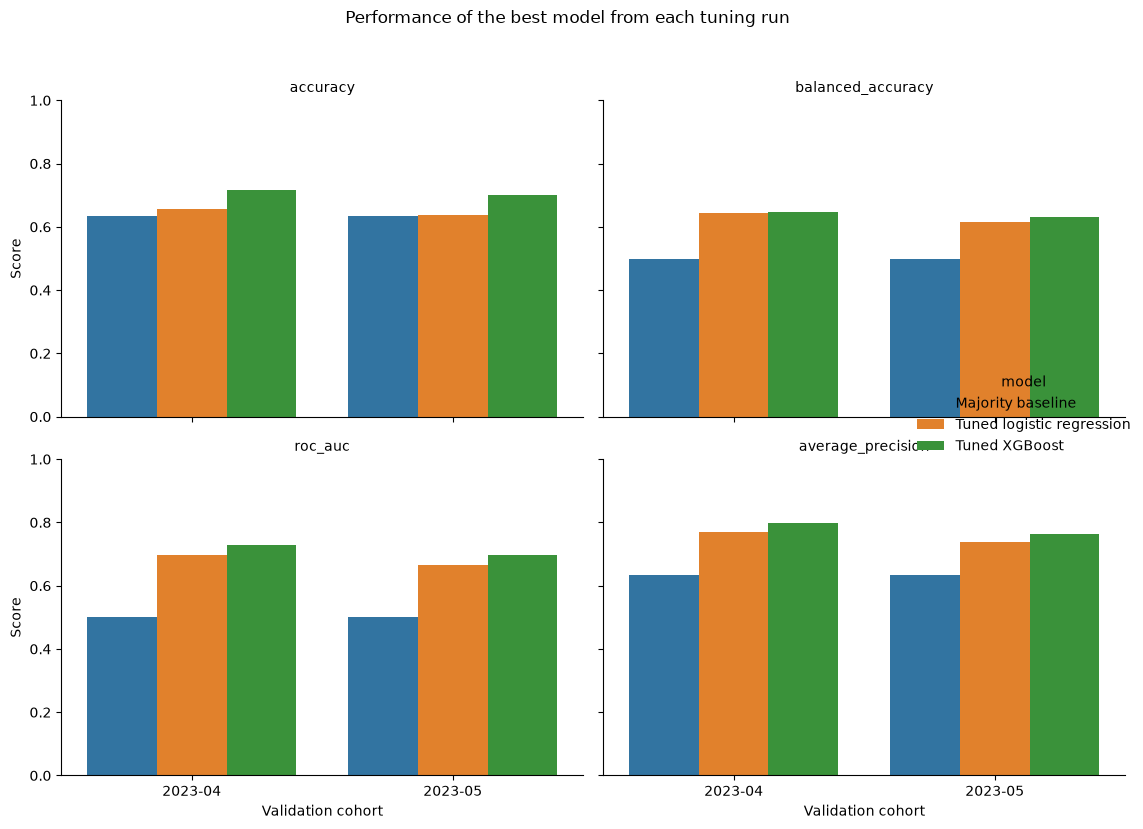

In [16]:
comparison_metrics = [
    "accuracy",
    "balanced_accuracy",
    "roc_auc",
    "average_precision",
]

model_order = [
    "Majority baseline",
    "Tuned logistic regression",
    "Tuned XGBoost",
]

plot_metrics = fold_metrics.melt(
    id_vars=["model", "validation_period"],
    value_vars=comparison_metrics,
    var_name="metric",
    value_name="score",
)

g = sns.catplot(
    data=plot_metrics,
    x="validation_period",
    y="score",
    hue="model",
    hue_order=model_order,
    col="metric",
    col_wrap=2,
    kind="bar",
    height=4,
    aspect=1.15,
    sharey=True,
)

g.set_axis_labels("Validation cohort", "Score")
g.set_titles("{col_name}")
g.figure.suptitle(
    "Performance of the best model from each tuning run",
    y=1.03,
)

for ax in g.axes.flat:
    ax.set_ylim(0, 1)

g.figure.tight_layout()
plt.show()

# Conclusion

After comparing the models on the out-of-time tuning folds, we conclude:

- Both logistic regression and XGBoost outperform the majority-class baseline. Balanced accuracy and ROC AUC are particularly important here because ordinary accuracy can be misleading when the target classes are imbalanced.
- XGBoost achieves the strongest overall performance across the April and May validation cohorts and is therefore selected as the final model candidate.
- The differences between training and temporal-validation performance are relatively modest, providing no strong evidence of severe overfitting. However, this conclusion remains provisional because the hyperparameters were selected using these validation folds and only two cohorts are available.
- The selected XGBoost configuration and classification threshold must now be evaluated exactly once on the untouched June 2023 holdout. This will provide a less biased estimate of its performance on future customers.